# Build Network and Compute Betweenness Centrality with NetworKit

## Cleaned network data

Install packages

In [1]:
%pip install networkit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkit as nk
import importlib.metadata

try:
    version = importlib.metadata.version('networkit')
    print(f"NetworKit version: {version}")
except importlib.metadata.PackageNotFoundError:
    print("NetworKit is not installed.")

NetworKit version: 11.2


In [3]:
from networkit import vizbridges
from networkit import graph
from networkit import graphio

In [4]:
%pip install contextily
import contextily as ctx
import pandas as pd 
%pip install geopandas
import geopandas as gpd
%pip install matplotlib 
import matplotlib.pyplot as plt
import networkx as nx
%pip install seaborn
import seaborn as sns 
import numpy as np

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Read in Data

In [5]:
# Read with NetworkX first
G_nx = nx.read_graphml('street_network_graph-clean.graphml')

# Convert to NetworKit
G_nk = nk.nxadapter.nx2nk(G_nx)

In [6]:
# Verify the graph
print("Nodes:", G_nk.numberOfNodes())
print("Edges:", G_nk.numberOfEdges())
print("Directed:", G_nk.isDirected())
print("Weighted:", G_nk.isWeighted())

Nodes: 21202
Edges: 32061
Directed: False
Weighted: False


In [7]:
# Map network graph node coordinates to unique sequential Node IDs starting from 0
coord_to_node = {}
node_counter = 0

for node in G_nx.nodes():
    x = G_nx.nodes[node]['x']
    y = G_nx.nodes[node]['y']
    coord = (x, y)
    
    # Map coordinate to sequential node ID
    if coord not in coord_to_node:
        coord_to_node[coord] = node_counter
        node_counter += 1

print(f"Total unique nodes mapped: {len(coord_to_node)}")
print("Sample coordinate to node ID mapping:", list(coord_to_node.items())[:5])

Total unique nodes mapped: 21202
Sample coordinate to node ID mapping: [((1272454.59576377, 196821.621245593), 0), ((1272445.65285176, 196530.332157284), 1), ((1272798.19742812, 229164.418078706), 2), ((1272804.96216413, 229595.832927153), 3), ((1281723.54604527, 282410.519317225), 4)]


Build Test Network 

In [8]:
# # Build test networkx graph
# from networkx.generators.lattice import grid_2d_graph

# m = 50
# n = 50
# G_test =grid_2d_graph(m, n, periodic=False, create_using=None)

# # Verify the graph is created
# print("Number of nodes:", G_test.number_of_nodes())
# print("Number of edges:", G_test.number_of_edges())

In [9]:
# # assign latitude and longitude to each node
# pos = {(x, y): (y, -x) for x, y in G_test.nodes()}
# nx.set_node_attributes(G_test, pos, 'pos')
# # Draw the graph
# plt.figure(figsize=(10, 10))
# nx.draw(G_test, pos, node_size=10, node_color='blue', edge_color='gray')
# plt.title("Test Grid Graph")
# plt.show()

In [10]:
# # Map network graph node coordinates to unique sequential Node IDs starting from 0
# coord_to_node = {}
# node_counter = 0

# for node in G_test.nodes():
#     # For grid_2d_graph, the node itself is a tuple (x, y)
#     x, y = node
#     coord = (x, y)
    
#     # Map coordinate to sequential node ID
#     if coord not in coord_to_node:
#         coord_to_node[coord] = node_counter
#         node_counter += 1

# print(f"Total unique nodes mapped: {len(coord_to_node)}")
# print("Sample coordinate to node ID mapping:", list(coord_to_node.items())[:5])

In [11]:
# # Set up NetworKit graph from NetworkX graph
# G_nk = nk.nxadapter.nx2nk(G_test)

Save Graph Data

In [12]:
# Create a DataFrame from the node list with coordinates and sequential node IDs
node_list = [{'Node ID': node_id, 'Longitude': coord[0], 'Latitude': coord[1]} for coord, node_id in coord_to_node.items()]

# Convert the list to a DataFrame
df_nodes = pd.DataFrame(node_list)

# Save the DataFrame to a CSV file
df_nodes.to_csv('node_list.csv', index=False)

# Print the DataFrame to verify
print(f"Created {len(df_nodes)} nodes")
print(df_nodes.head())

Created 21202 nodes
   Node ID     Longitude       Latitude
0        0  1.272455e+06  196821.621246
1        1  1.272446e+06  196530.332157
2        2  1.272798e+06  229164.418079
3        3  1.272805e+06  229595.832927
4        4  1.281724e+06  282410.519317


In [13]:
# Create a DataFrame from the edge list
edge_list = [{'Source': edge[0], 'Target': edge[1], 'Weight': G_nk.weight(edge[0], edge[1])} for edge in G_nk.iterEdges()]

# Convert the list to a DataFrame
df_edges = pd.DataFrame(edge_list)

# Save the DataFrame to a CSV file
df_edges.to_csv('edge_list.csv', index=False)

# Print the DataFrame to verify
print(df_edges)

       Source  Target  Weight
0           0       1     1.0
1           0    2489     1.0
2           0    9563     1.0
3           0   10059     1.0
4           1    9324     1.0
...       ...     ...     ...
32056   21170   21182     1.0
32057   21176   21177     1.0
32058   21178   21179     1.0
32059   21178   21181     1.0
32060   21197   21198     1.0

[32061 rows x 3 columns]


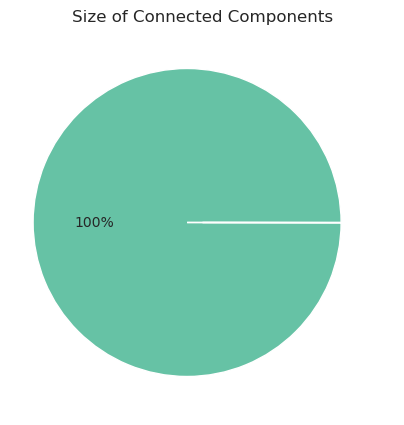

In [14]:
# Plot connected components sizes of the network 
nk.plot.connectedComponentsSizes(G_nk, relativeSizes=True)

In [15]:
# Extract the largest connected component of the graph
# Step 1: Find connected components
cc = nk.components.ConnectedComponents(G_nk)
cc.run()
components = cc.getComponents()

# Step 2: Sort the connected components by size in descending order
components_sorted = sorted(components, key=len, reverse=True)

# Step 3: Check if there are any connected components
if components_sorted:
    # Create a subgraph for analysis using the largest connected component
    largest_component = components_sorted[0]
    G_sub = nk.graphtools.subgraphFromNodes(G_nk, largest_component)
    print("Subgraph created with", G_sub.numberOfNodes(), "nodes and", G_sub.numberOfEdges(), "edges.")
else:
    print("No connected components found in the graph.")


Subgraph created with 21197 nodes and 32057 edges.


## Compute Network Metrics ##

In [16]:
# Profiling overall picture of the network
import warnings
warnings.filterwarnings('ignore')
nk.profiling.Profile.create(G_nk).show()

Network Structural Profile 
 
	<!--- HELP --->
 Navigating the profile 
 
 the profile includes the following sections by default: 
 
 global properties 
 overview of node centrality and partition distributions 
 detail views of node centrality distributions 
 node centrality correlations 
 detail views of partitions 
 
 click [+] for descriptions of measures 
 click on distribution thumbnail for detail view 
 hover over variable name of statistical figures for explanation 
 click on distribution plot for larger view 
 
 
	<!--- END HELP --->
 
 21202 
 32061 
 0.000142651 
 False 
 False 
 0 
 (112, 123) 
 N/A 
 2 
 
 
 
 <img src="data:image/svg+xml;utf8,%3Csvg%20xmlns%3Axlink%3D%22http%3A%2F%2Fwww.w3.org%2F1999%2Fxlink%22%20width%3D%22288pt%22%20height%3D%22180pt%22%20viewBox%3D%220%200%20288%20180%22%20xmlns%3D%22http%3A%2F%2Fwww.w3.org%2F2000%2Fsvg%22%20version%3D%221.1%22%3E%20%3Cmetadata%3E%20%3Crdf%3ARDF%20xmlns%3Adc%3D%22http%3A%2F%2Fpurl.org%2Fdc%2Felements%2F1.1%2F%22%20xmlns%3Acc%3D%22http%3A%2F%2Fcreativecommons.org%2Fns%23%22%20xmlns%3Ardf%3D%22http%3A%2F%2Fwww.w3.org%2F1999%2F02%2F22-rdf-syntax-ns%23%22%3E%20%3Ccc%3AWork%3E%20%3Cdc%3Atype%20rdf%3Aresource%3D%22http%3A%2F%2Fpurl.org%2Fdc%2Fdcmitype%2FStillImage%22%2F%3E%20%3Cdc%3Adate%3E2026-01-08T12%3A26%3A36.282383%3C%2Fdc%3Adate%3E%20%3Cdc%3Aformat%3Eimage%2Fsvg%2Bxml%3C%2Fdc%3Aformat%3E%20%3Cdc%3Acreator%3E%20%3Ccc%3AAgent%3E%20%3Cdc%3Atitle%3EMatplotlib%20v3.10.0%2C%20https%3A%2F%2Fmatplotlib.org%2F%3C%2Fdc%3Atitle%3E%20%3C%2Fcc%3AAgent%3E%20%3C%2Fdc%3Acreator%3E%20%3C%2Fcc%3AWork%3E%20%3C%2Frdf%3ARDF%3E%20%3C%2Fmetadata%3E%20%3Cdefs%3E%20%3Cstyle%20type%3D%22text%2Fcss%22%3E%2A%7Bstroke-linejoin%3A%20round%3B%20stroke-linecap%3A%20butt%7D%3C%2Fstyle%3E%20%3C%2Fdefs%3E%20%3Cg%20id%3D%22figure_1%22%3E%20%3Cg%20id%3D%22patch_1%22%3E%20%3Cpath%20d%3D%22M%200%20180%20L%20288%20180%20L%20288%200%20L%200%200%20z%20%22%20style%3D%22fill%3A%20%23ffffff%22%2F%3E%20%3C%2Fg%3E%20%3Cg%20id%3D%22axes_1%22%3E%20%3Cg%20id%3D%22patch_2%22%3E%20%3Cpath%20d%3D%22M%2043.36%20138.04%20L%20263.12%20138.04%20L%20263.12%2010.8%20L%2043.36%2010.8%20z%20%22%20style%3D%22fill%3A%20%23ffffff%22%2F%3E%20%3C%2Fg%3E%20%3Cg%20id%3D%22matplotlib.axis_1%22%3E%20%3Cg%20id%3D%22xtick_1%22%3E%20%3Cg%20id%3D%22line2d_1%22%3E%20%3Cpath%20d%3D%22M%2080.568042%20138.04%20L%2080.568042%2010.8%20%22%20clip-path%3D%22url%28%23p387f67a034%29%22%20style%3D%22fill%3A%20none%3B%20stroke%3A%20%23d3d3d3%3B%20stroke-width%3A%200.8%3B%20stroke-linecap%3A%20round%22%2F%3E%20%3C%2Fg%3E%20%3Cg%20id%3D%22text_1%22%3E%20%3C%21--%20%24%5Cmathdefault%7B2%7D%24%20--%3E%20%3Cg%20transform%3D%22translate%2877.368042%20152.638438%29%20scale%280.1%20-0.1%29%22%3E%20%3Cdefs%3E%20%3Cpath%20id%3D%22DejaVuSans-32%22%20d%3D%22M%201228%20531%20L%203431%20531%20L%203431%200%20L%20469%200%20L%20469%20531%20Q%20828%20903%201448%201529%20Q%202069%202156%202228%202338%20Q%202531%202678%202651%202914%20Q%202772%203150%202772%203378%20Q%202772%203750%202511%203984%20Q%202250%204219%201831%204219%20Q%201534%204219%201204%204116%20Q%20875%204013%20500%203803%20L%20500%204441%20Q%20881%204594%201212%204672%20Q%201544%204750%201819%204750%20Q%202544%204750%202975%204387%20Q%203406%204025%203406%203419%20Q%203406%203131%203298%202873%20Q%203191%202616%202906%202266%20Q%202828%202175%202409%201742%20Q%201991%201309%201228%20531%20z%20%22%20transform%3D%22scale%280.015625%29%22%2F%3E%20%3C%2Fdefs%3E%20%3Cuse%20xlink%3Ahref%3D%22%23DejaVuSans-32%22%20transform%3D%22translate%280%200.78125%29%22%2F%3E%20%3C%2Fg%3E%20%3C%2Fg%3E%20%3C%2Fg%3E%20%3Cg%20id%3D%22xtick_2%22%3E%20%3Cg%20id%3D%22line2d_2%22%3E%20%3Cpath%20d%3D%22M%20138.705608%20138.04%20L%20138.705608%2010.8%20%22%20clip-path%3D%22url%28%23p387f67a034%29%22%20style%3D%22fill%3A%20none%3B%20stroke%3A%20%23d3d3d3%3B%20stroke-width%3A%200.8%3B%20stroke-linecap%3A%20round%22%2F%3E%20%3C%2Fg%3E%20%3Cg%20id%3D%22text_2%22%3E%20%3C%21--%20%24%5Cmathdefault%7B4%7D%24%20--%3E%20%3Cg%20transf

Degree Distribution

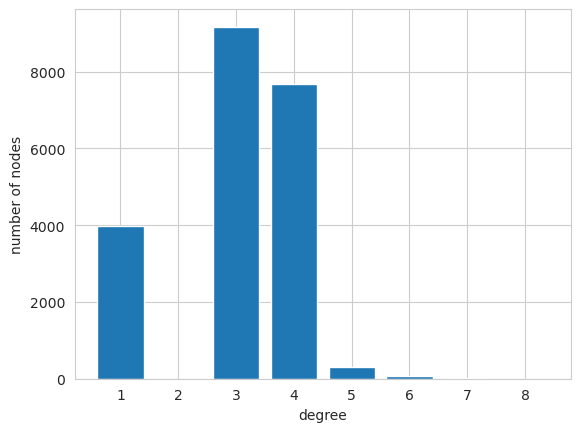

In [37]:
# Plot Degree Distribution of the Network
dd = sorted(nk.centrality.DegreeCentrality(G_nk).run().scores(), reverse=True)
degrees, numberOfNodes = np.unique(dd, return_counts=True)
plt.xlabel("degree")
plt.ylabel("number of nodes")
plt.bar(degrees, numberOfNodes)
plt.show()

Average Degree

In [18]:
print("Average degree of Network = ",2*G_nk.numberOfEdges()/G_nk.numberOfNodes())
print("Average degree of Subnetwork = ",2*G_sub.numberOfEdges()/G_sub.numberOfNodes())

Average degree of Network =  3.0243373266672955
Average degree of Subnetwork =  3.0246733028258714


Average Clustering Coefficient

In [19]:
# Calculate the average clustering coefficient for the entire network
clustering_coefficient = nk.centrality.LocalClusteringCoefficient(G_nk)
clustering_coefficient.run()
average_clustering_coefficient = sum(clustering_coefficient.scores()) / G_nk.numberOfNodes()
print("Average Clustering Coefficient of Network =", average_clustering_coefficient)

Average Clustering Coefficient of Network = 0.029212091401979147


In [20]:
# Calculate the average clustering coefficient for the sub network
clustering_coefficient = nk.centrality.LocalClusteringCoefficient(G_sub)
clustering_coefficient.run()
average_clustering_coefficient = sum(clustering_coefficient.scores()) / G_sub.numberOfNodes()
print("Average Clustering Coefficient of Sub Network =", average_clustering_coefficient)

Average Clustering Coefficient of Sub Network = 0.029218982021265362


## Centrality ##

Degree Centrality

In [21]:
# Initialize algorithm
deg = nk.centrality.DegreeCentrality(G_nk)
deg.run()
deg_centrality = deg.scores() 

In [22]:
# Add degree centrality scores to the Node List DataFrame
df_nodes['Degree Centrality'] = df_nodes['Node ID'].map(lambda node: deg_centrality[node])

# Save the DataFrame to a CSV file
df_nodes.to_csv('node_list_dc.csv', index=False)

# Print the DataFrame to verify
print(df_nodes.head())

   Node ID     Longitude       Latitude  Degree Centrality
0        0  1.272455e+06  196821.621246                4.0
1        1  1.272446e+06  196530.332157                4.0
2        2  1.272798e+06  229164.418079                3.0
3        3  1.272805e+06  229595.832927                4.0
4        4  1.281724e+06  282410.519317                3.0


In [23]:
# 10 most central nodes according to degree centrality are
central_nodes_deg = deg.ranking()[:10]

# Convert the list to a Most Central Nodes DataFrame
df_central_nodes_dc = pd.DataFrame(central_nodes_deg, columns=['Node ID', 'Degree Centrality'])

# Merge the central nodes DataFrame with the node list DataFrame to add coordinates
df_central_nodes_dc = df_central_nodes_dc.merge(df_nodes[['Node ID', 'Longitude', 'Latitude']], on='Node ID')

# Save the DataFrame to a CSV file
df_central_nodes_dc.to_csv('central_nodes_dc.csv', index=False)

print("Most central nodes in Subnetwork according to Degree Centrality:")
df_central_nodes_dc

Most central nodes in Subnetwork according to Degree Centrality:


,Node ID,Degree Centrality,Longitude,Latitude
0,6149,8.0,1.271167e+06,240877.595499
1,1942,7.0,1.267666e+06,245187.426415
2,2373,7.0,1.263080e+06,212184.875277
3,3588,7.0,1.266982e+06,241771.472620
4,8801,7.0,1.266669e+06,238218.813736
5,12899,7.0,1.270195e+06,198446.500863
6,16606,7.0,1.265570e+06,212268.688141
7,18063,7.0,1.269793e+06,221193.780503
8,19080,7.0,1.270307e+06,231478.613281
9,296,6.0,1.269220e+06,171298.076195


Betweenness Centrality

In [24]:
# Initalize algorithm
btwn = nk.centrality.Betweenness(G_sub)

In [25]:
# Run 
btwn.run()

In [26]:
btwn_centrality = btwn.scores() 

In [27]:
# Add betweenness centrality scores to the Node List DataFrame
df_nodes['Betweenness Centrality'] = df_nodes['Node ID'].map(lambda node: btwn_centrality[node])

# Save the DataFrame to a CSV file
df_nodes.to_csv('node_list_dc_btwn.csv', index=False)

# Print the DataFrame to verify
print(df_nodes.head())

   Node ID     Longitude       Latitude  Degree Centrality  \
0        0  1.272455e+06  196821.621246                4.0   
1        1  1.272446e+06  196530.332157                4.0   
2        2  1.272798e+06  229164.418079                3.0   
3        3  1.272805e+06  229595.832927                4.0   
4        4  1.281724e+06  282410.519317                3.0   

   Betweenness Centrality  
0            1.276094e+05  
1            1.702251e+05  
2            3.162100e+06  
3            7.362791e+04  
4            8.272782e+04  


In [28]:
# 10 most central nodes according to betweenness centrality are
central_nodes_btwn = btwn.ranking()[:10]

# Convert the list to a Most Central Nodes DataFrame
df_central_nodes_btwn = pd.DataFrame(central_nodes_btwn, columns=['Node ID', 'Betweenness Centrality'])

# Merge the central nodes DataFrame with the node list DataFrame to add coordinates
df_central_nodes_btwn = df_central_nodes_btwn.merge(df_nodes[['Node ID', 'Longitude', 'Latitude']], on='Node ID')

# Save the DataFrame to a CSV file
df_central_nodes_btwn.to_csv('central_nodes_btwn.csv', index=False)

print("Most central nodes in Subnetwork according to Betweenness Centrality:")
df_central_nodes_btwn

Most central nodes in Subnetwork according to Betweenness Centrality:


,Node ID,Betweenness Centrality,Longitude,Latitude
0,15619,1.809184e+08,1.273446e+06,242840.059053
1,15886,1.704418e+08,1.272295e+06,233460.752995
2,15634,1.541496e+08,1.271711e+06,230180.395744
3,17297,1.530056e+08,1.273637e+06,246714.367921
4,15673,1.508123e+08,1.271700e+06,229532.444959
5,15672,1.473236e+08,1.271412e+06,224797.240794
6,15861,1.428622e+08,1.271918e+06,223858.961881
7,15618,1.348591e+08,1.274038e+06,251126.435893
8,19574,1.243217e+08,1.271974e+06,258235.828156
9,15853,1.079605e+08,1.273526e+06,217714.443283


Analyze Results

In [29]:
# Read the CSV file
df_bc = pd.read_csv('node_list_dc_btwn.csv')

# Assuming the CSV has a column named 'Betweenness Centrality'
bc_values = df_bc['Betweenness Centrality'].values

In [30]:
mean_bc = df_bc['Betweenness Centrality'].mean()
mean_bc

np.float64(915947.3797754961)

In [31]:
max(bc_values) 

np.float64(180918375.89595225)

In [32]:
sorted_bc = df_bc.sort_values(by='Betweenness Centrality', ascending=True)
sorted_bc.head(20000)

,Node ID,Longitude,Latitude,Degree Centrality,Betweenness Centrality
13704,13704,1.280828e+06,209156.217610,1.0,0.000000e+00
13643,13643,1.274184e+06,215569.638225,1.0,0.000000e+00
13648,13648,1.266863e+06,286316.688985,1.0,0.000000e+00
13649,13649,1.290335e+06,249111.333619,1.0,0.000000e+00
13723,13723,1.282053e+06,283119.042838,1.0,0.000000e+00
...,...,...,...,...,...
10401,10401,1.262459e+06,195147.074044,4.0,2.905862e+06
10564,10564,1.268656e+06,232081.019554,3.0,2.906391e+06
17406,17406,1.297187e+06,185899.966578,3.0,2.909128e+06
2188,2188,1.275642e+06,266599.549253,4.0,2.911412e+06


In [33]:
# Filter out nodes with zero betweenness centrality
node_list_bc_nozeros = df_bc[df_bc['Betweenness Centrality'] > 0]

# Save the filtered nodes to a new CSV file
node_list_bc_nozeros.to_csv('node_list_bc_nozeros.csv', index=False)

In [34]:
# Caluclate the logarithm of the betweenness centrality values and add them to the DataFrame

# Define DataFrame
df = node_list_bc_nozeros

# Calculate the logarithm of the betweenness centrality values
df['LogBetweennessCentrality'] = np.log(df['Betweenness Centrality'])

print(df.head())

   Node ID     Longitude       Latitude  Degree Centrality  \
0        0  1.272455e+06  196821.621246                4.0   
1        1  1.272446e+06  196530.332157                4.0   
2        2  1.272798e+06  229164.418079                3.0   
3        3  1.272805e+06  229595.832927                4.0   
4        4  1.281724e+06  282410.519317                3.0   

   Betweenness Centrality  LogBetweennessCentrality  
0            1.276094e+05                 11.756729  
1            1.702251e+05                 12.044877  
2            3.162100e+06                 14.966747  
3            7.362791e+04                 11.206779  
4            8.272782e+04                 11.323311  


In [35]:
# save the new DataFrame to a CSV file
df.to_csv('node_list_bc_nozeros_log.csv', index=False)

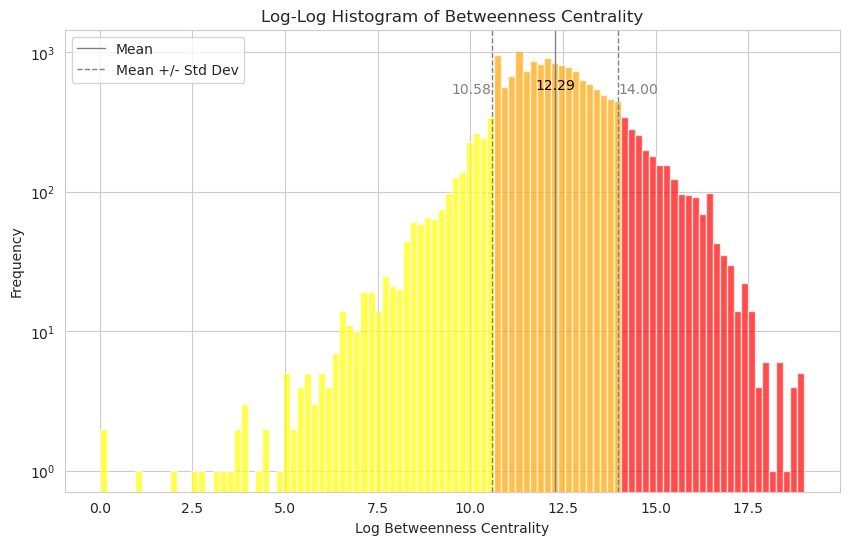

In [ ]:
# Plot log-log histogram of betweenness centrality

# Read the CSV file
df_bc = pd.read_csv('node_list_bc_nozeros_log.csv')

# Assuming the CSV has a column named 'LogBetweennessCentrality'
bc_values = df_bc['LogBetweennessCentrality'].values

# Add mean and standard deviation to the plot
mean_bc = np.mean(bc_values)
std_bc = np.std(bc_values)

# Calculate histogram data
hist, bin_edges = np.histogram(bc_values, bins=100)

# Plot the histogram with different colors
plt.figure(figsize=(10, 6))
for i in range(len(bin_edges) - 1):
    # Use bin center for color assignment to better align with mean/std lines
    bin_center = (bin_edges[i] + bin_edges[i + 1]) / 2
    
    if bin_center < mean_bc - std_bc:
        color = 'yellow'  # Below mean - std
    elif bin_center <= mean_bc + std_bc:
        color = 'orange'  # Between mean - std and mean + std
    else:
        color = 'red'  # Above mean + std
    plt.bar(bin_edges[i], hist[i], width=bin_edges[i + 1] - bin_edges[i], color=color, align='edge', alpha=0.7)

# Add mean and standard deviation lines
plt.axvline(mean_bc, color='gray', linestyle='solid', linewidth=1, label='Mean')
plt.axvline(mean_bc + std_bc, color='gray', linestyle='dashed', linewidth=1, label='Mean +/- Std Dev')
plt.axvline(mean_bc - std_bc, color='gray', linestyle='dashed', linewidth=1)

# Add text annotations for mean and standard deviation
plt.text(mean_bc, plt.ylim()[1] * 0.5, f'{mean_bc:.2f}', color='black', ha='center')
plt.text(mean_bc + std_bc, plt.ylim()[1] * 0.5, f'{mean_bc + std_bc:.2f}', color='gray', ha='left', va='center')
plt.text(mean_bc - std_bc, plt.ylim()[1] * 0.5, f'{mean_bc - std_bc:.2f}', color='gray', ha='right', va='center')

# Set log scale for y-axis
plt.yscale('log')

# Add labels and title
plt.xlabel('Log Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Log-Log Histogram of Betweenness Centrality')

# Add legend
plt.legend(loc='upper left')

# Show the plot
plt.savefig('betweenness_centrality_log_histogram.pdf')
plt.show()